In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
from torch import nn
from torch.nn import functional as F
import copy

import sys
import os
import pathlib
import pickle
import itertools
from typing import Callable

from omegaconf import OmegaConf

import tqdm.notebook as tqdm

In [2]:
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src')

import data_preparation
import models_gnn
import model_loader
import losses
import run_experiment

In [3]:
device = torch.device('cpu')

if torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='cuda')

In [4]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\neighbors_init\dump_neighbors_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    target_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/neighbors_init/dump_neighbors_init_seed_269_adj_269.bin')


In [5]:
# path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\random_init\dump_random_init_seed_269_adj_4615.bin')
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\pos_init\dump_pos_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    random_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/pos_init/dump_pos_init_seed_269_adj_269.bin')


<Axes: >

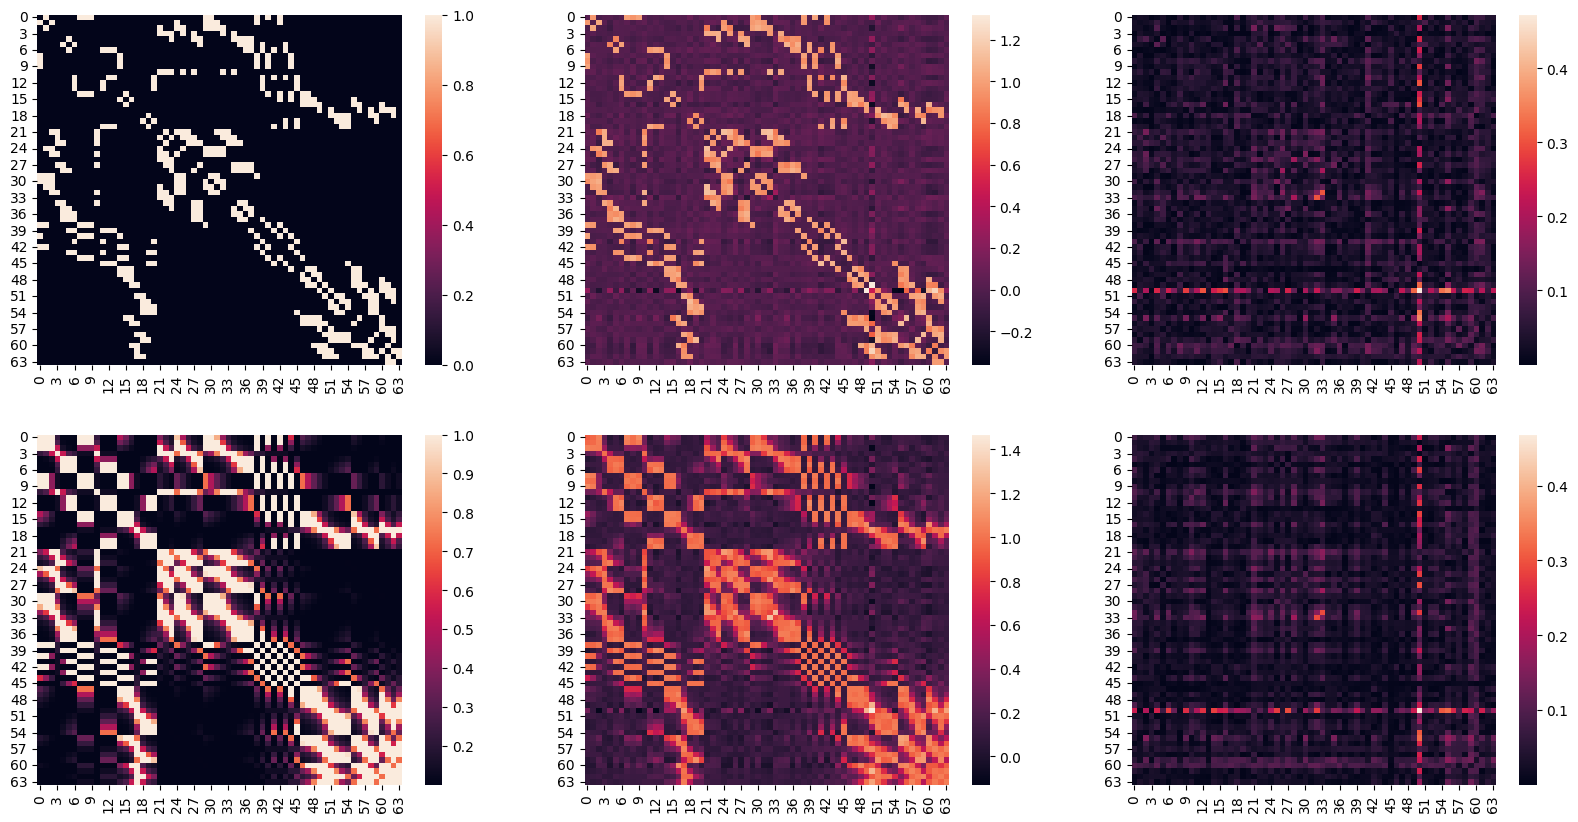

In [6]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

adj_init = target_run_info['adj']['init']
adj_final = target_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = random_run_info['adj']['init']
adj_final = random_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

In [7]:
def adj_conv(adj_1: torch.Tensor, adj_2: torch.Tensor) -> Callable:
    def conv(theta: float) -> torch.Tensor:
        return adj_2 * theta + adj_1 * (1.0 -  theta)
    
    return conv

In [8]:
def get_nn(base_nn, adj_matrix, cfg):
    if isinstance(adj_matrix, np.ndarray):
        adj_matrix = torch.from_numpy(adj_matrix)

    adj_layer = models_gnn.AdjLayer(
        n_channels=cfg.n_channels, 
        init_mat=adj_matrix,
        is_sym=cfg.adj_sym
    )

    base_nn.gc.adj = adj_layer

    return base_nn

In [9]:
@torch.inference_mode
def score_model(model: nn.Module, dataloader: torch.utils.data.DataLoader, criterion: losses.HybridLoss):
    model.eval()
    running_TP, running_TN, running_FP, running_FN = 0, 0, 0, 0
    running_loss = 0.0
    num_objs = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs_size = inputs.size(0)

        outputs = model(inputs)
        loss = criterion(input=outputs, target=labels, adj=model.gc.adj.adj_mat)

        _, preds = torch.max(outputs, 1)
        _, true_y = torch.max(labels.data, 1)

        P = torch.sum(preds)
        N = torch.sum(1 - preds)
        TP = torch.sum(torch.masked_select(true_y, preds == 1))
        TN = torch.sum(torch.masked_select(1 - true_y, preds == 0))
        FP = P - TP
        FN = N - TN

        running_loss += loss.item() * inputs_size
        running_TP += TP.item()
        running_TN += TN.item()
        running_FP += FP.item()
        running_FN += FN.item()
        num_objs += inputs_size

    running_loss = running_loss / num_objs

    return {
        'loss': running_loss,
        'TP': running_TP,
        'TN': running_TN,
        'FP': running_FP,
        'FN': running_FN,
    }

In [10]:
def calc_accuracy(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return (TP + TN) / (TP + TN + FP + FN)

def calc_recall(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FN)

def calc_precision(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FP)

def calc_f1(TP: int, TN: int, FP: int, FN: int, **kwargs):
    precision = calc_precision(TP=TP, TN=TN, FP=FP, FN=FN)
    recall = calc_recall(TP=TP, TN=TN, FP=FP, FN=FN)

    f1 = 2 * precision * recall / (precision + recall)

    return f1

# Замороженные веса

In [ ]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_dataset, test_dataset = data_preparation.load_dataset(cfg)
_, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

criterion = model_loader.load_criterion(cfg)

In [ ]:
train_res = run_experiment.run(cfg_path)

In [ ]:
base_nn = copy.deepcopy(train_res['model'])

base_nn

In [ ]:
# base_nn = get_nn(base_nn, adj_matrix=random_run_info['adj']['init'])
# base_nn = get_nn(base_nn, adj_matrix=target_run_info['adj']['init'])

# base_nn.gc.adj.adj_mat

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=random_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=target_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
adj_geodetic = adj_conv(
    # adj_1=random_run_info['adj']['final'],
    adj_1=train_res['logs']['adj']['final'],
    adj_2=target_run_info['adj']['final']
)
criterion = model_loader.load_criterion(cfg)

thetas = np.linspace(0.0, 1.0, num=500)

f1_ls = np.zeros_like(thetas)
acc_ls = np.zeros_like(thetas)
loss_ls = np.zeros_like(thetas)

for i, theta in enumerate(thetas):
    adj_mat = adj_geodetic(theta)
    mid_model = get_nn(base_nn, adj_matrix=adj_mat).to(device)

    scores = score_model(mid_model, test_dataloader, criterion)
    f1 = calc_f1(**scores)
    accuracy = calc_accuracy(**scores)

    f1_ls[i] = f1
    acc_ls[i] = accuracy
    loss_ls[i] = scores['loss']

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

# Обучение с различными инициализациями

In [11]:
def run_sample(theta: float, adj_geodetic):
    cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_cfg.yaml'
    work_cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_working.yaml'
    init_dump_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\viewer_adj_init.bin'

    # uploading config
    cfg = OmegaConf.load(cfg_path)
    cfg['run_name'] = f'viewer_{theta=:.4f}'.replace('.', '')
    cfg['adj_init'] = init_dump_path

    with open(work_cfg_path, 'w') as f:
        print(
            OmegaConf.to_yaml(cfg, resolve=True),
            file=f
        )
    
    # uploading adj_init
    adj = adj_geodetic(theta)
    if isinstance(adj, np.ndarray):
        adj = torch.from_numpy(adj)
    with open(init_dump_path, 'wb') as f:
        pickle.dump(
            obj=adj,
            file=f
        )

    train_res = run_experiment.run(work_cfg_path)

    return train_res

In [12]:
train_res_ls = []

thetas = np.linspace(0.0, 1.0, num=41)
adj_geodetic = adj_conv(
    adj_1=random_run_info['adj']['init'],
    adj_2=target_run_info['adj']['init']
)

for i, theta in tqdm.tqdm(enumerate(thetas), total=len(thetas)):
    train_res = run_sample(theta, adj_geodetic)
    train_res_ls.append(train_res)

  0%|          | 0/41 [00:00<?, ?it/s]

tensor([42,  0,  0,  ...,  0,  0,  0], dtype=torch.uint8)


C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati


100%|██████████| 200/200 [05:23<00:00,  1.62s/it]


train/FN,█▃▇▆▅▅▅▅▄▄▃▅▃▃▃▃▄▄▃▃▄▄▃▂▃▂▂▂▂▃▂▂▁▂▂▁▁▂▁▁
train/FP,█▅▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▁▂▂▂▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/TN,▁▁▂▂▂▃▃▃▃▃▃▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇
train/TP,▂▁▂▂▃▄▃▃▃▄▄▄▄▆▅▅▅▅▄▅▆▆▇▆▅▇▇▇▆█▇▆▇▇▇▇▇▇██
train/epoch_acc,▁▁▂▂▂▃▃▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train/epoch_bc,▁▃▃▃▃▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇▇███████████
train/epoch_f1,▁▁▂▂▃▃▃▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇█▇▇████
train/epoch_ones,▇█▅▄▃▃▃▃▂▃▂▂▂▁▁▂▂▂▁▁▁▁▂▂▁▁▂▂▁▂▁▁▁▂▂▂▂▂▂▂
train/epoch_precision,▁▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████████
train/epoch_recall,▂▆▅▂▁▁▂▃▃▃▄▄▄▅▄▃▄▅▅▅▆▆▆▇▇▆▇▇▇▇▆█▇▇▇█████
train/loss,██▇▇▆▆▆▆▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁


...

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x000001AD03E9B4C0>, {'TP': [7320, 7792, 8336, 8288, 8158, 8044, 8064, 7990, 8012, 8192, 8193, 8128, 8114, 8197, 8204, 8213, 8044, 8227, 8186, 8178, 8247, 8090, 8183, 8168, 8167, 8132, 8043, 8145, 8144, 8094, 8090, 8156, 8195, 8157, 8172, 8269, 8205, 8272, 8180, 8194, 8273, 8258, 8286, 8308, 8329, 8291, 8363, 8329, 8404, 8273, 8449, 8383, 8356, 8330, 8414, 8393, 8413, 8543, 8451, 8529, 8467, 8582, 8621, 8638, 8595, 8586, 8568, 8637, 8572, 8538, 8512, 8538, 8505, 8557, 8567, 8533, 8576, 8493, 8564, 8567, 8585, 8560, 8520, 8624, 8561, 8537, 8589, 8610, 8585, 8575, 8664, 8630, 8615, 8664, 8677, 8583, 8630, 8615, 8706, 8754, 8631, 8702, 8536, 8627, 8803, 8755, 8658, 8644, 8760, 8769, 8733, 8739, 8724, 8687, 8747, 8742, 8661, 8670, 8680, 8777, 8678, 8819, 8733, 8734, 8651, 8684, 8700, 8625, 8729, 8804, 8617, 8765, 8710, 8696, 8727, 8572, 8724, 8721, 8717, 8772, 8693, 8665, 8643, 8826, 8713, 8791, 8716, 8738, 8656, 8714, 8671


  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)

  4%|▎         | 3/85 [00:00<00:02, 29.14it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWa


100%|██████████| 200/200 [05:29<00:00,  1.65s/it]


train/FN,█▆▄▅▅▅▅▄▄▄▄▄▄▃▃▃▄▃▃▂▂▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▂▂
train/FP,█▆▅▄▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁
train/TN,▁▁▂▃▄▄▅▆▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████
train/TP,▃▂▁▂▂▂▂▂▄▅▆▅▅▅▆▆▅▅▅▆▆▇▇▇▇▆▆▆▇█▇▇▇█▇▇▇███
train/epoch_acc,▁▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train/epoch_bc,▁▁▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
train/epoch_f1,▁▄▄▅▅▆▅▆▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
train/epoch_ones,▅▇█▆▅▄▄▃▂▂▂▂▃▃▃▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▁▂▁▂▂▂▂▂▁▁
train/epoch_precision,▁▃▃▃▃▅▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇█▇███
train/epoch_recall,▁▃▄▅▅▅▅▅▄▅▅▅▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█
train/loss,█▆▅▅▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁


train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x000001AD0F14A8E0>, {'TP': [7321, 7790, 8318, 8292, 8160, 8039, 8088, 8028, 8053, 8237, 8216, 8113, 8111, 8172, 8194, 8198, 8061, 8229, 8217, 8168, 8270, 8060, 8191, 8141, 8155, 8131, 8027, 8149, 8147, 8125, 8127, 8172, 8205, 8180, 8232, 8314, 8225, 8296, 8232, 8273, 8319, 8291, 8305, 8294, 8370, 8276, 8418, 8369, 8421, 8303, 8442, 8388, 8354, 8335, 8427, 8418, 8455, 8542, 8480, 8525, 8482, 8586, 8644, 8637, 8568, 8535, 8541, 8620, 8547, 8579, 8504, 8514, 8565, 8583, 8598, 8525, 8546, 8513, 8587, 8555, 8579, 8602, 8528, 8651, 8594, 8569, 8606, 8581, 8616, 8582, 8664, 8688, 8671, 8680, 8711, 8639, 8684, 8707, 8758, 8759, 8616, 8702, 8602, 8665, 8846, 8769, 8684, 8697, 8775, 8756, 8720, 8746, 8783, 8679, 8771, 8730, 8683, 8732, 8695, 8790, 8657, 8798, 8730, 8676, 8624, 8717, 8686, 8659, 8682, 8746, 8618, 8750, 8690, 8684, 8777, 8590, 8753, 8776, 8766, 8808, 8701, 8697, 8686, 8818, 8712, 8811, 8795, 8777, 8625, 8721, 8726

In [13]:
train_res_ls[0]['logs']['train_curve']['validation'].keys()

dict_keys(['TP', 'TN', 'FP', 'FN', 'accuracy', 'f1', 'loss'])

In [14]:
with open(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\viewer_curves\neighbors_to_pos.bin', 'wb') as f:
    pickle.dump(train_res_ls, file=f)

In [15]:
best_step_idxs = []
best_f1 = []
best_acc = []
best_loss = []

for train_res in train_res_ls:
    f1_scores = train_res['logs']['train_curve']['validation']['f1']
    acc_scores = train_res['logs']['train_curve']['validation']['accuracy']
    loss = train_res['logs']['train_curve']['validation']['loss']
    best_idx = np.argmax(f1_scores)

    best_step_idxs.append(best_idx)
    best_f1.append(f1_scores[best_idx])
    best_acc.append(acc_scores[best_idx])
    best_loss.append(loss[best_idx])

best_step_idxs = np.array(best_step_idxs)
best_f1 = np.array(best_f1)
best_acc = np.array(best_acc)

Text(0, 0.5, 'Loss')

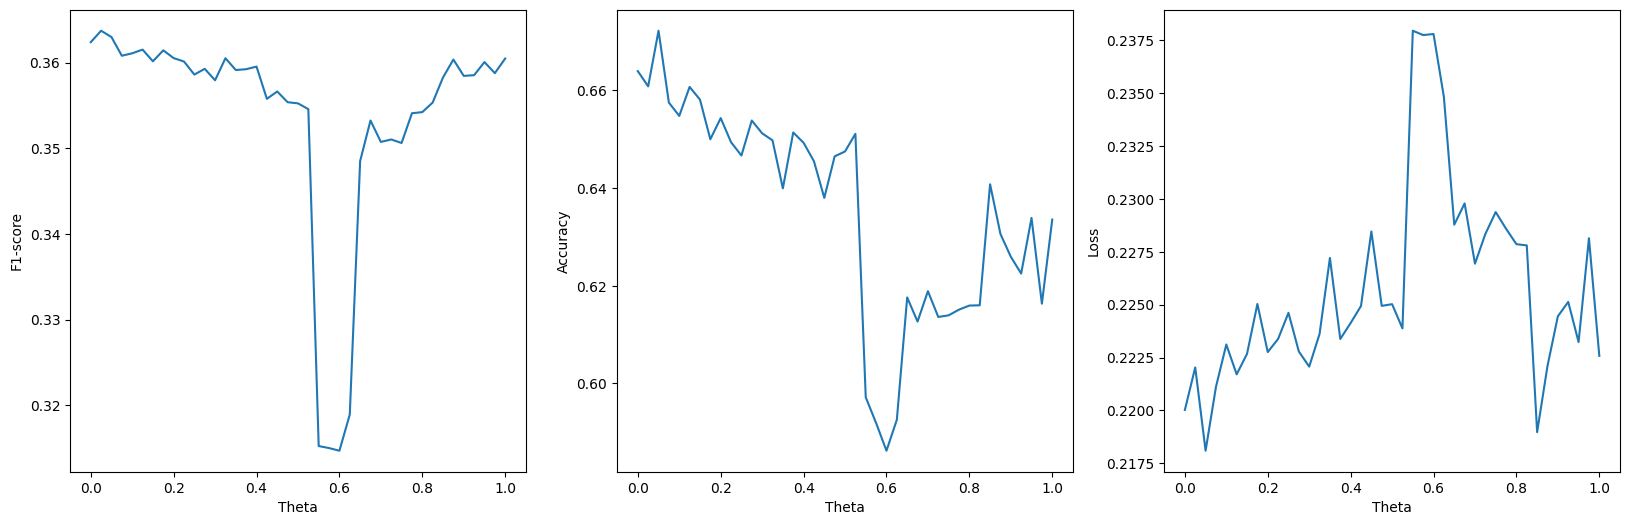

In [16]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, best_f1)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, best_acc)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, best_loss)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

In [17]:
idx = np.argmin(best_acc)

print(f"Worst results: F1={best_f1[idx]:.4f}\tAcc={best_acc[idx]:.4f}\tLoss={best_loss[idx]:.4f}")

Worst results: F1=0.3147	Acc=0.5862	Loss=0.2378


<Axes: >

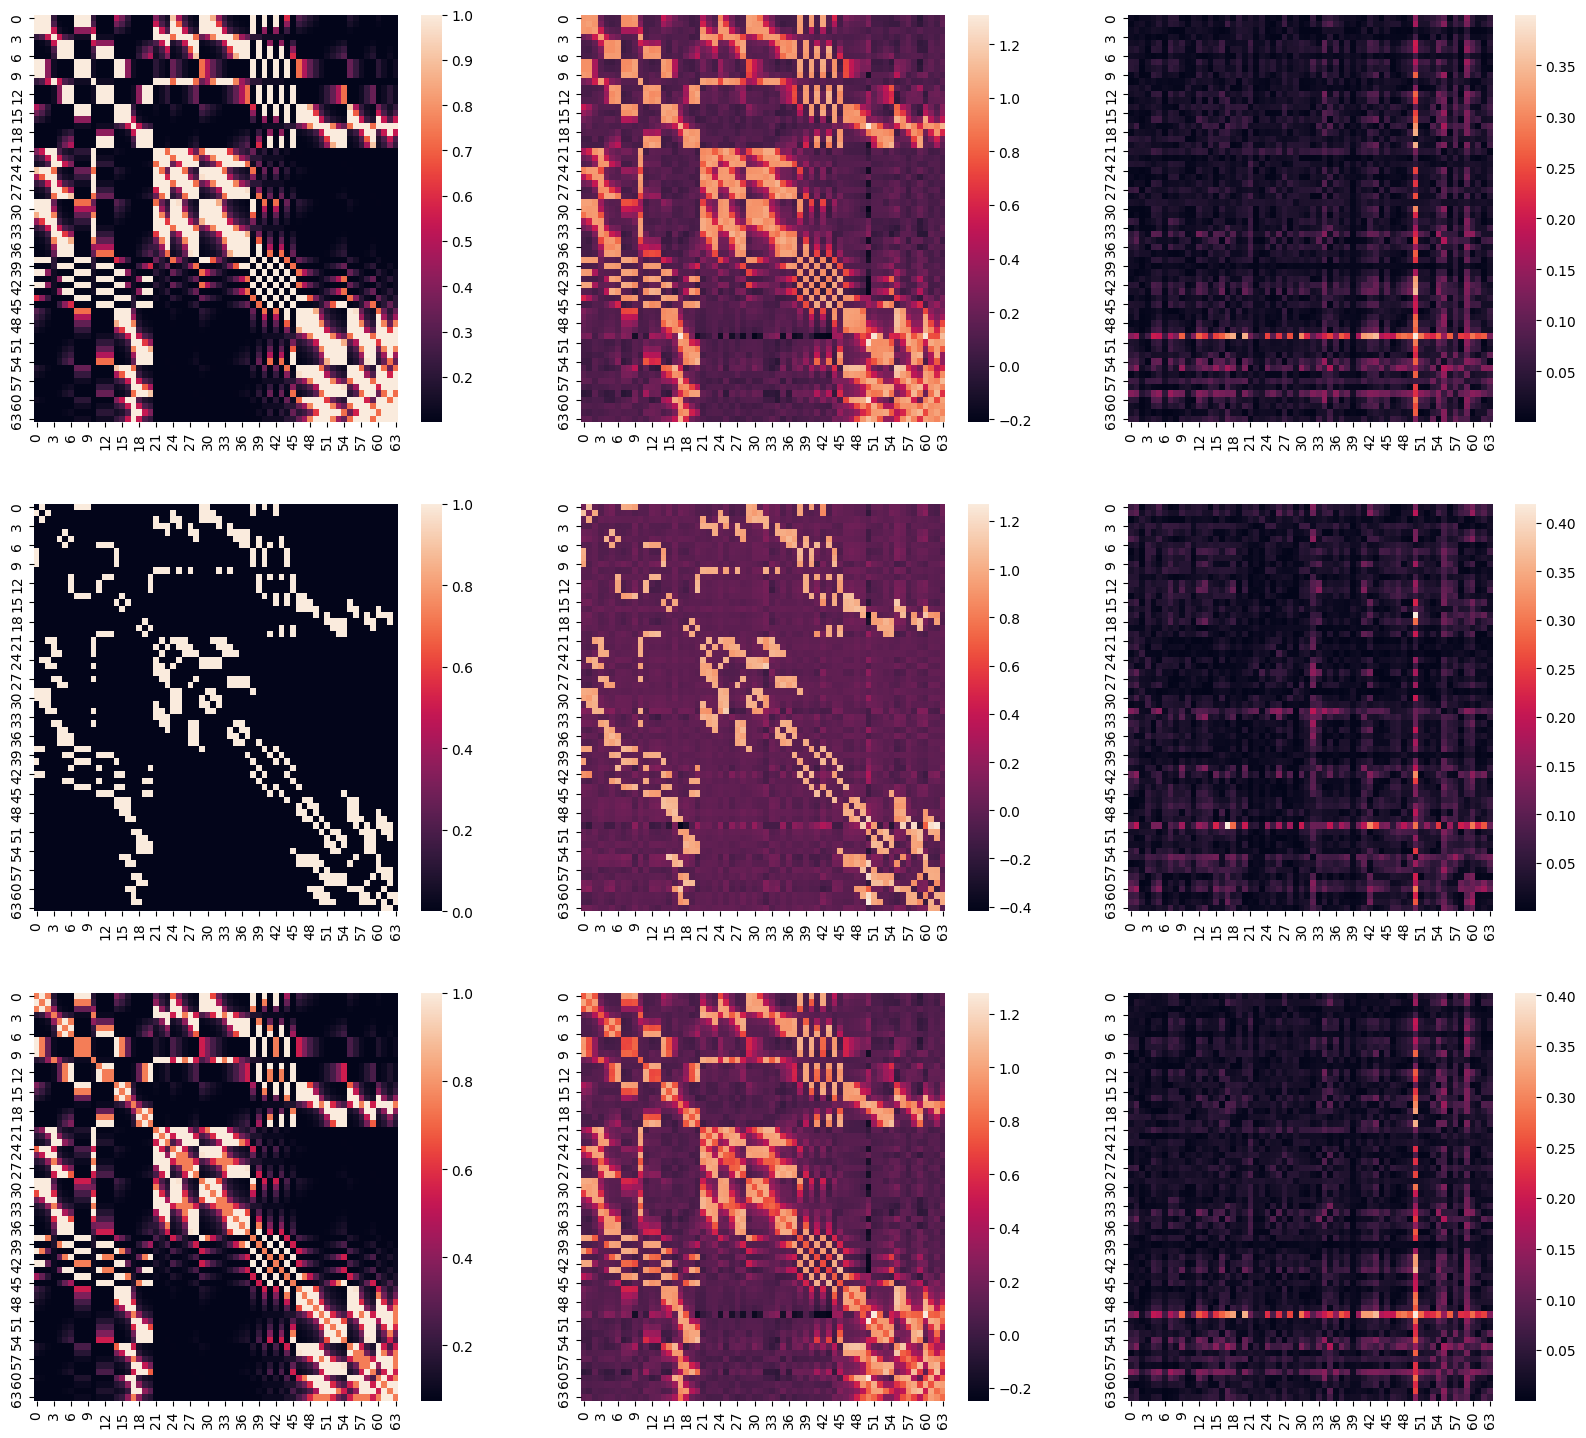

In [18]:
_, ax = plt.subplots(ncols=3, nrows=3, figsize=(20, 18))

adj_init = train_res_ls[0]['logs']['adj']['init']
adj_final = train_res_ls[0]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = train_res_ls[-1]['logs']['adj']['init']
adj_final = train_res_ls[-1]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

delta = -idx + 10
adj_init = train_res_ls[idx + delta]['logs']['adj']['init']
adj_final = train_res_ls[idx + delta]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[2, 0])
sns.heatmap(adj_final, ax=ax[2, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[2, 2])

In [19]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_dataset, test_dataset = data_preparation.load_dataset(cfg)
train_dataloader, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

criterion = model_loader.load_criterion(cfg)

  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
  5%|▍         | 4/85 [00:00<00:02, 34.60it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarn

KeyboardInterrupt: 

In [111]:
adj_masked = copy.deepcopy(train_res_ls[0]['logs']['adj']['final'])

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

raw_scores = {
    'validation': score_model(masked_nn, test_dataloader, criterion),
    'train': score_model(masked_nn, train_dataloader, criterion)
}

print("Validation:")
print(f"\tLoss={raw_scores['validation']['loss']:.4f}\tAccuracy={calc_accuracy(**raw_scores['validation']):.4f}\tF1-score={calc_f1(**raw_scores['validation']):.4f}")

print("Train:")
print(f"\tLoss={raw_scores['train']['loss']:.4f}\tAccuracy={calc_accuracy(**raw_scores['train']):.4f}\tF1-score={calc_f1(**raw_scores['train']):.4f}")

Validation:
	Loss=0.2204	Accuracy=0.6496	F1-score=0.3545
Train:
	Loss=0.2011	Accuracy=0.6968	F1-score=0.6995


In [84]:
mask = np.zeros_like(adj_final, dtype=bool)
mask[50, :] = True
mask[:, 50] = True

adj_masked = np.where(
    mask,
    train_res_ls[0]['logs']['adj']['final'],
    0.0
)

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

scores = score_model(masked_nn, test_dataloader, criterion)

print(f"Loss={scores['loss']:.4f}\tAccuracy={calc_accuracy(**scores):.4f}\tF1-score={calc_f1(**scores):.4f}")

Loss=0.2491	Accuracy=0.6168	F1-score=0.2728


In [85]:
mask = np.ones_like(adj_final, dtype=bool)
mask[50, :] = False
mask[:, 50] = False

adj_masked = np.where(
    mask,
    train_res_ls[0]['logs']['adj']['final'],
    0.0
)

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

scores = score_model(masked_nn, test_dataloader, criterion)

print(f"Loss={scores['loss']:.4f}\tAccuracy={calc_accuracy(**scores):.4f}\tF1-score={calc_f1(**scores):.4f}")

Loss=0.2432	Accuracy=0.6228	F1-score=0.2913


In [127]:
masked_f1 = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}
masked_acc = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}
masked_loss = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}

masked_nn = copy.deepcopy(train_res_ls[0]['model'])

for i in tqdm.tqdm(range(64)):
    for j in range(i, 64):
        mask = np.ones_like(adj_final, dtype=bool)
        mask[i, j] = False
        mask[j, i] = False

        adj_masked = np.where(
            mask,
            train_res_ls[0]['logs']['adj']['final'],
            0.0
        )

        masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

        for ds_split, dataloader in zip(
            ('train', 'validation'),
            (train_dataloader, test_dataloader),
            ):
            
            scores = score_model(masked_nn, dataloader, criterion)

            masked_f1[ds_split][i, j] = calc_f1(**scores)
            masked_acc[ds_split][i, j] = calc_accuracy(**scores)
            masked_loss[ds_split][i, j] = scores['loss']

            masked_f1[ds_split][j, i] = masked_f1[ds_split][i, j]
            masked_acc[ds_split][j, i] = masked_acc[ds_split][i, j]
            masked_loss[ds_split][j, i] = masked_loss[ds_split][i, j]

  0%|          | 0/64 [00:00<?, ?it/s]

In [ ]:
# with open(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\viewer\masked_scores_sym.bin', 'wb') as f:
#     pickle.dump(
#         obj=(masked_f1, masked_acc, masked_loss, raw_scores),
#         file=f
#     )

Text(0.5, 1.0, 'Loss')

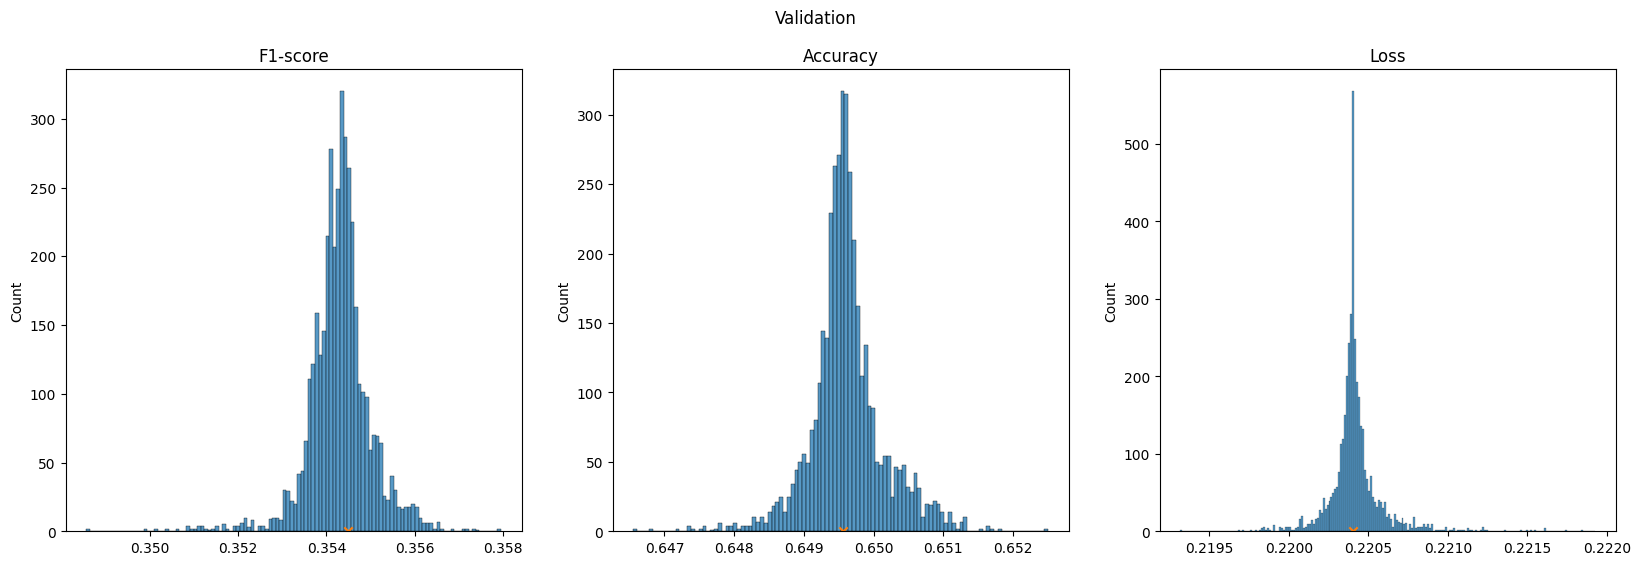

In [129]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 6))
fig.suptitle('Validation')

sns.histplot(
    masked_f1['validation'].ravel(),
    ax=ax[0]
)
ax[0].scatter([calc_f1(**raw_scores['validation'])], [0], marker='x')
ax[0].set_title('F1-score')


sns.histplot(
    masked_acc['validation'].ravel(),
    ax=ax[1]
)
ax[1].scatter([calc_accuracy(**raw_scores['validation'])], [0], marker='x')
ax[1].set_title('Accuracy')


sns.histplot(
    masked_loss['validation'].ravel(),
    ax=ax[2]
)
ax[2].scatter([raw_scores['validation']['loss']], [0], marker='x')
ax[2].set_title('Loss')

Text(0.5, 1.0, 'Loss')

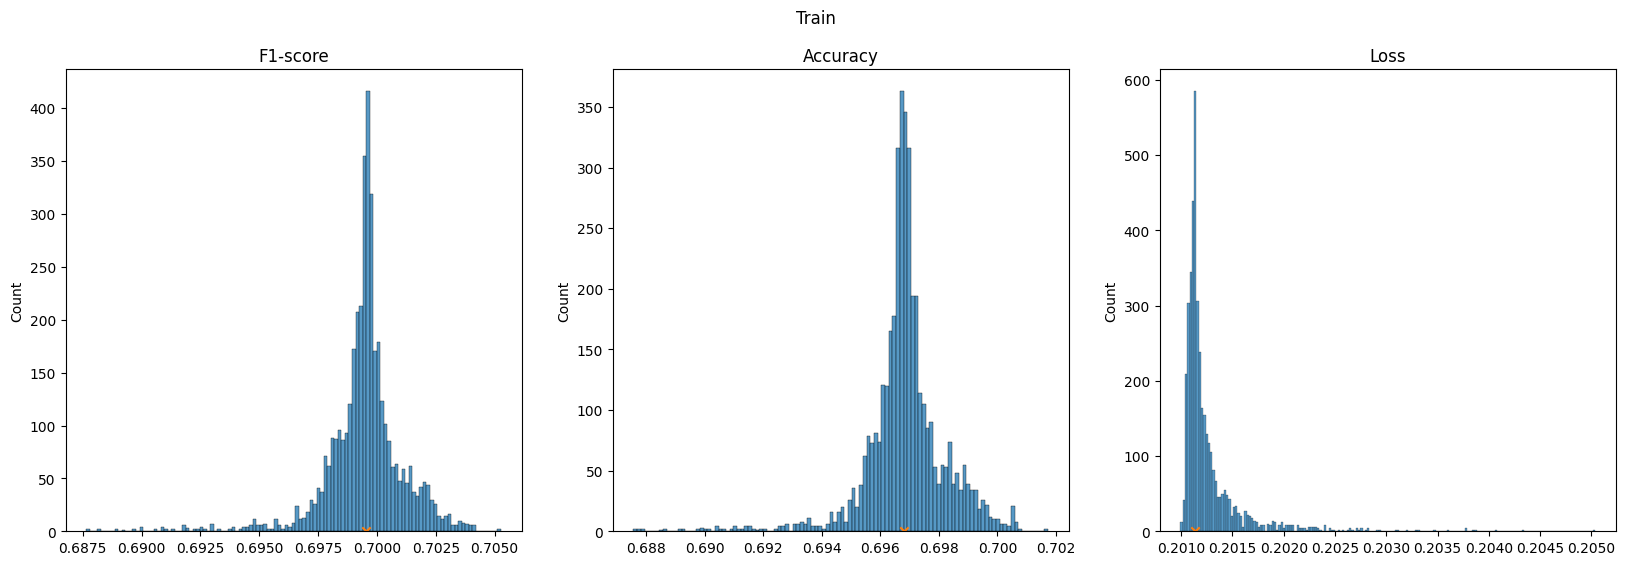

In [130]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 6))
fig.suptitle('Train')

sns.histplot(
    masked_f1['train'].ravel(),
    ax=ax[0]
)
ax[0].scatter([calc_f1(**raw_scores['train'])], [0], marker='x')
ax[0].set_title('F1-score')


sns.histplot(
    masked_acc['train'].ravel(),
    ax=ax[1]
)
ax[1].scatter([calc_accuracy(**raw_scores['train'])], [0], marker='x')
ax[1].set_title('Accuracy')


sns.histplot(
    masked_loss['train'].ravel(),
    ax=ax[2]
)
ax[2].scatter([raw_scores['train']['loss']], [0], marker='x')
ax[2].set_title('Loss')

Text(0.5, 1.0, 'Train, neg-loss')

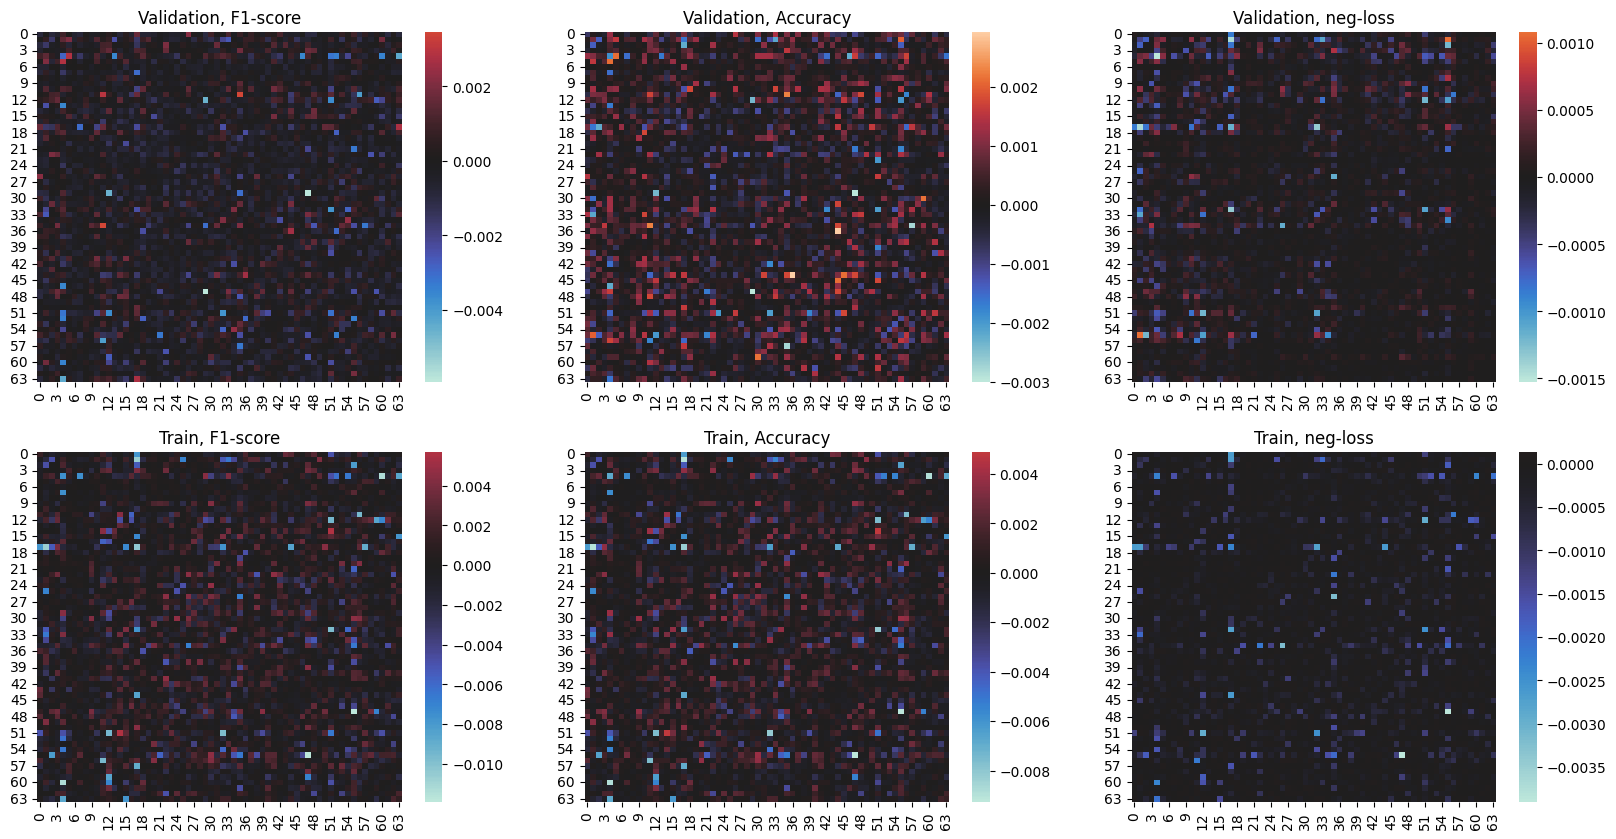

In [131]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

# Validation
sns.heatmap(
    masked_f1['validation'] - calc_f1(**raw_scores['validation']),
    center=0,
    ax=ax[0, 0]
)
ax[0, 0].set_title('Validation, F1-score')

sns.heatmap(
    masked_acc['validation'] - calc_accuracy(**raw_scores['validation']),
    center=0,
    ax=ax[0, 1]
)
ax[0, 1].set_title('Validation, Accuracy')

sns.heatmap(
    -(masked_loss['validation'] - raw_scores['validation']['loss']),
    center=0,
    ax=ax[0, 2]
)
ax[0, 2].set_title('Validation, neg-loss')


# Train
sns.heatmap(
    masked_f1['train'] - calc_f1(**raw_scores['train']),
    center=0,
    ax=ax[1, 0]
)
ax[1, 0].set_title('Train, F1-score')

sns.heatmap(
    masked_acc['train'] - calc_accuracy(**raw_scores['train']),
    center=0,
    ax=ax[1, 1]
)
ax[1, 1].set_title('Train, Accuracy')

sns.heatmap(
    -(masked_loss['train'] - raw_scores['train']['loss']),
    center=0,
    ax=ax[1, 2]
)
ax[1, 2].set_title('Train, neg-loss')